<a href="https://colab.research.google.com/github/plexisad/CS531ML_Learning/blob/main/Mini_Project_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Jeff Legg

CS 536 Intro to Machine Learning

Mini Project Milestone 2

# Task 1: Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Make plots look a little nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("open-source-sports/baseball-databank")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'baseball-databank' dataset.
Path to dataset files: /kaggle/input/baseball-databank


##Data Set Overview

In [4]:
batting = pd.read_csv(f"{path}/Batting.csv")
pitching = pd.read_csv(f"{path}/Pitching.csv")
salaries = pd.read_csv(f"{path}/Salaries.csv")

print(batting.shape)
print(pitching.shape)
print(salaries.shape)

(101332, 22)
(44139, 30)
(25575, 5)


In [5]:
print(batting.columns.tolist())
print(pitching.columns.tolist())
print(salaries.columns.tolist())

['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']
['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'IPouts', 'H', 'ER', 'HR', 'BB', 'SO', 'BAOpp', 'ERA', 'IBB', 'WP', 'HBP', 'BK', 'BFP', 'GF', 'R', 'SH', 'SF', 'GIDP']
['yearID', 'teamID', 'lgID', 'playerID', 'salary']


In [6]:
bat_pitch = batting.merge(
    pitching,
    on=["playerID", "yearID", "teamID"],
    how="left",
    suffixes=("_bat", "_pit")
)

print(bat_pitch.shape)

(101364, 49)


In [7]:
baseball = bat_pitch.merge(
    salaries,
    on=["playerID", "yearID", "teamID"],
    how="left"
)

print(baseball.shape)
baseball.head()

(101364, 51)


,playerID,yearID,stint_bat,teamID,lgID_bat,G_bat,AB,R_bat,H_bat,2B,...,HBP_pit,BK,BFP,GF,R_pit,SH_pit,SF_pit,GIDP_pit,lgID,salary
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
baseball.tail()

,playerID,yearID,stint_bat,teamID,lgID_bat,G_bat,AB,R_bat,H_bat,2B,...,HBP_pit,BK,BFP,GF,R_pit,SH_pit,SF_pit,GIDP_pit,lgID,salary
101359,zitoba01,2015,1,OAK,AL,3,0.0,0.0,0.0,0.0,...,0.0,0.0,37.0,1.0,8.0,0.0,0.0,NaN,NaN,NaN
101360,zobribe01,2015,1,OAK,AL,67,235.0,39.0,63.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AL,7500000.0
101361,zobribe01,2015,2,KCA,AL,59,232.0,37.0,66.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101362,zuninmi01,2015,1,SEA,AL,112,350.0,28.0,61.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AL,523500.0
101363,zychto01,2015,1,SEA,AL,13,0.0,0.0,0.0,0.0,...,2.0,0.0,76.0,4.0,6.0,0.0,0.0,NaN,NaN,NaN


##Feature Summary

In [11]:
print(f"Dataset Shape: {baseball.shape}")

baseball.info()

Dataset Shape: (101364, 51)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101364 entries, 0 to 101363
Data columns (total 51 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   playerID   101364 non-null  object 
 1   yearID     101364 non-null  int64  
 2   stint_bat  101364 non-null  int64  
 3   teamID     101364 non-null  object 
 4   lgID_bat   100627 non-null  object 
 5   G_bat      101364 non-null  int64  
 6   AB         96215 non-null   float64
 7   R_bat      96215 non-null   float64
 8   H_bat      96215 non-null   float64
 9   2B         96215 non-null   float64
 10  3B         96215 non-null   float64
 11  HR_bat     96215 non-null   float64
 12  RBI        95791 non-null   float64
 13  SB         94914 non-null   float64
 14  CS         72753 non-null   float64
 15  BB_bat     96215 non-null   float64
 16  SO_bat     88377 non-null   float64
 17  IBB_bat    59643 non-null   float64
 18  HBP_bat    93403 non-null   float64


## Missing Values

In [12]:
missing_values = baseball.isnull().sum()

missing_values

,0
playerID,0
yearID,0
stint_bat,0
teamID,0
lgID_bat,737
G_bat,0
AB,5149
R_bat,5149
H_bat,5149
2B,5149


##Summary Statistics


In [13]:
import pandas as pd

summary = baseball.describe().T

# Add the median
summary["Median"] = baseball.median(numeric_only=True)

# Remove columns you don't want
summary = summary.drop(columns=["count", "25%", "50%", "75%"])

# Reorder columns
summary = summary[[
    "mean",
    "Median",
    "std",
    "min",
    "max"
]]

# Rename columns
summary = summary.rename(columns={
    "mean": "Mean",
    "Median": "Median",
    "std": "Standard Deviation",
    "min": "Minimum",
    "max": "Maximum"
})

summary

,Mean,Median,Standard Deviation,Minimum,Maximum
yearID,1.963505e+03,1972.00,3.862989e+01,1871.0,2015.00
stint_bat,1.077888e+00,1.00,2.848419e-01,1.0,5.00
G_bat,5.138773e+01,34.00,4.714331e+01,0.0,165.00
AB,1.499242e+02,57.00,1.865435e+02,0.0,716.00
R_bat,1.988078e+01,5.00,2.866869e+01,0.0,192.00
H_bat,3.924931e+01,11.00,5.330643e+01,0.0,262.00
2B,6.634984e+00,1.00,9.800612e+00,0.0,67.00
3B,1.372956e+00,0.00,2.710199e+00,0.0,36.00
HR_bat,2.948345e+00,0.00,6.408815e+00,0.0,73.00
RBI,1.795941e+01,4.00,2.675391e+01,0.0,191.00


##Data Visualization

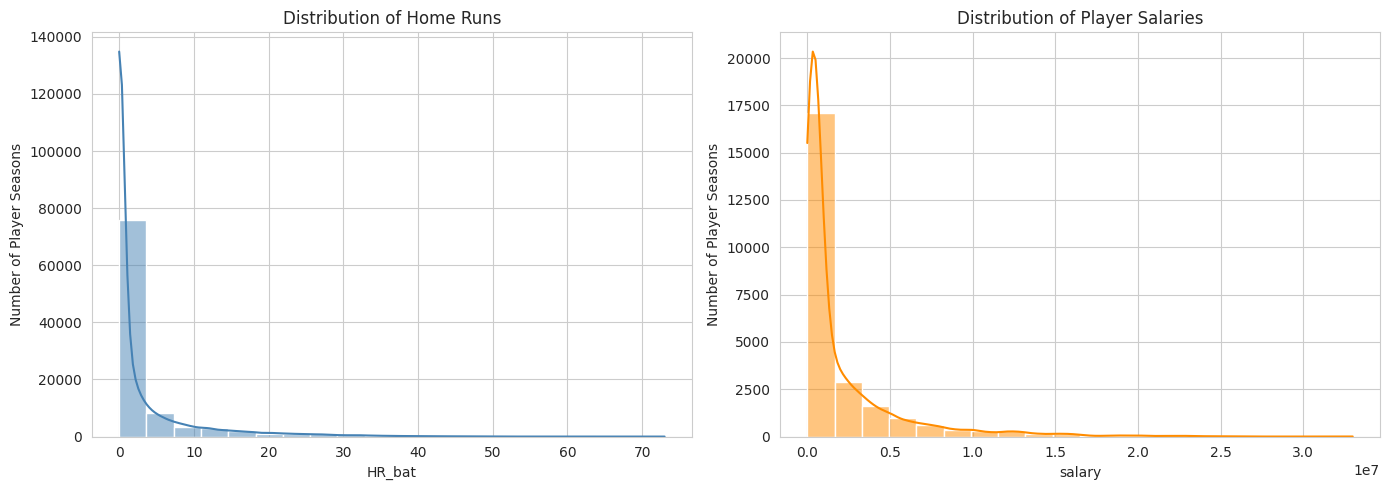

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["HR_bat", "salary"]
titles = [
    "Distribution of Home Runs",
    "Distribution of Player Salaries"
]
colors = ["steelblue", "darkorange"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(
        data=baseball.dropna(subset=[feature]),
        x=feature,
        bins=20,
        kde=True,
        color=color,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Player Seasons")

plt.tight_layout()
plt.show()

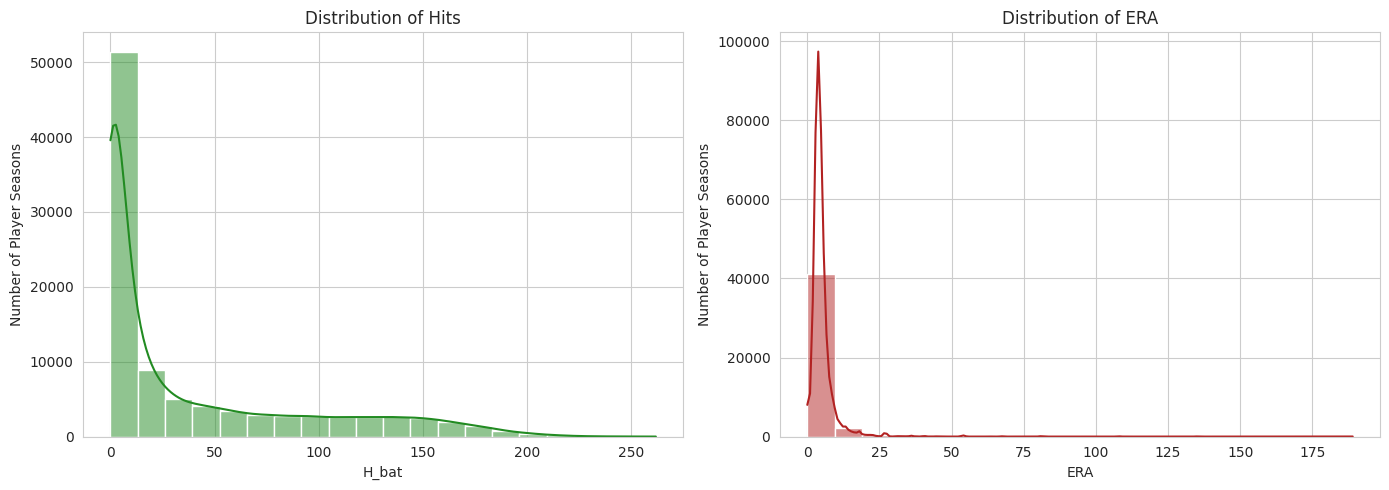

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["H_bat", "ERA"]
titles = [
    "Distribution of Hits",
    "Distribution of ERA"
]
colors = ["forestgreen", "firebrick"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(
        data=baseball,
        x=feature,
        bins=20,
        kde=True,
        color=color,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Player Seasons")

plt.tight_layout()
plt.show()

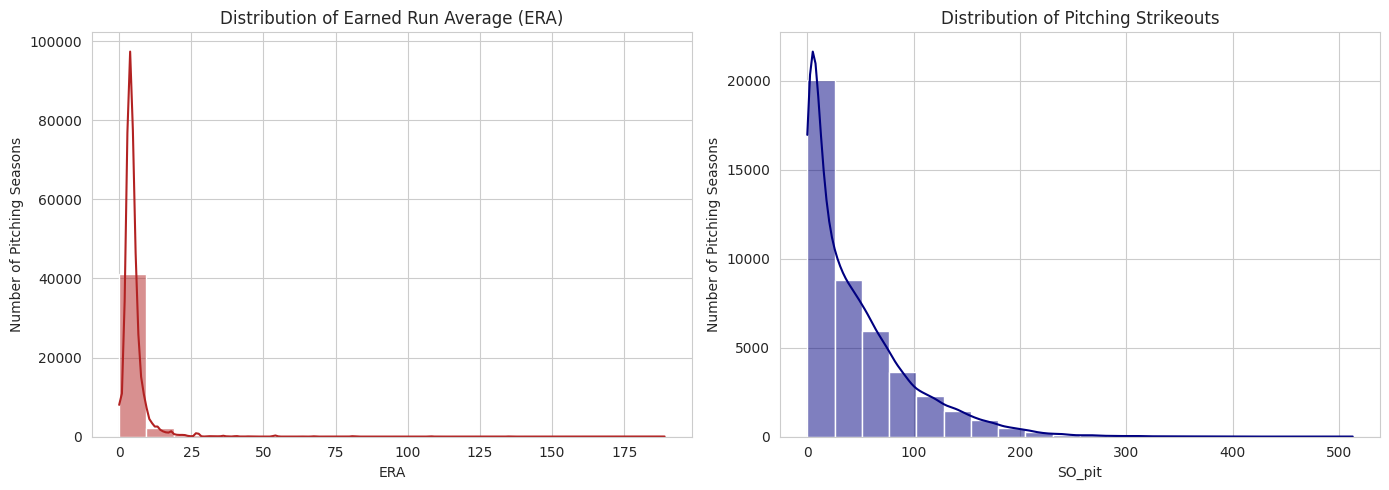

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["ERA", "SO_pit"]
titles = [
    "Distribution of Earned Run Average (ERA)",
    "Distribution of Pitching Strikeouts"
]
colors = ["firebrick", "navy"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(
        data=baseball.dropna(subset=[feature]),
        x=feature,
        bins=20,
        kde=True,
        color=color,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Pitching Seasons")

plt.tight_layout()
plt.show()